# Imports

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
import pandas as pd
import time
# from src.gmm import GMM,CovarianceType

In [2]:
from google.colab import files
print("Upload pca.py:")
uploaded = files.upload()
from PCA import NumpyPCA
from gmm import GMM, CovarianceType
from internal_metrics import (silhouette_score, davies_bouldin_index,
                              within_cluster_sum_squares, calinski_harabasz_index)
from external_metrics import adjusted_rand_index, normalized_mutual_information, purity


Upload pca.py:


Saving external_metrics.py to external_metrics.py
Saving gmm.py to gmm.py
Saving internal_metrics.py to internal_metrics.py
Saving PCA.py to PCA.py


## Load the breast cancer dataset

In [3]:
dataset = load_breast_cancer()
X=dataset.data
y=dataset.target

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {dataset.feature_names}")
print(f"\nClass distribution:")
print(f"Class 0 (malignant): {np.sum(y == 0)}")
print(f"Class 1 (benign): {np.sum(y == 1)}")

Dataset Information:
Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Class distribution:
Class 0 (malignant): 212
Class 1 (benign): 357


In [4]:
# Check for missing values
print(f"Missing values: {np.isnan(X).sum()}")  # Should be 0

Missing values: 0


### Standarize the data

In [5]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero for constant features
    std[std == 0] = 1

    X_scaled = (X - mean) / std

    return X_scaled, mean, std

In [6]:
# Standardize
X_scaled, mean, std = standardize(X)

print(f"Original - Mean: {X.mean():.2f}, Std: {X.std():.2f}")
print(f"Scaled   - Mean: {X_scaled.mean():.2f}, Std: {X_scaled.std():.2f}")

Original - Mean: 61.89, Std: 228.30
Scaled   - Mean: -0.00, Std: 1.00


### Using implemented PCA for visualization only

2D projection shape: (569, 2)
Variance explained by 2 components: 63.24%
Component 1 explains: 44.27%
Component 2 explains: 18.97%


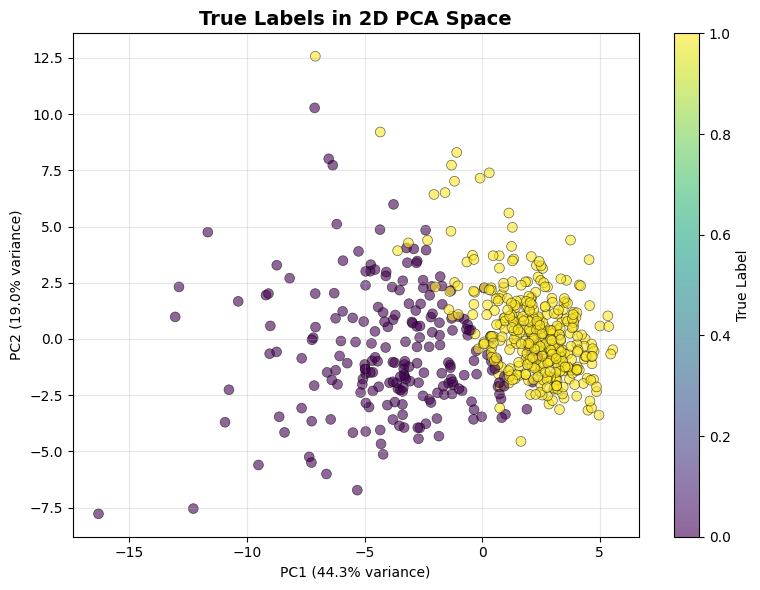

In [7]:
pca_2d = NumpyPCA(n_components=2)
pca_2d.fit(X_scaled)
X_2d = pca_2d.transform(X_scaled)

print(f"2D projection shape: {X_2d.shape}")
print(f"Variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"Component 1 explains: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"Component 2 explains: {pca_2d.explained_variance_ratio_[1]:.2%}")

# Visualize true labels in 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis',
                     alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
plt.colorbar(scatter, label='True Label')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('True Labels in 2D PCA Space', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

In [8]:
n_components_range = range(2, 8)
covariance_types = [CovarianceType.FULL, CovarianceType.TIED,
                    CovarianceType.DIAGONAL, CovarianceType.SPHERICAL]

all_results=[]

### Train

In [9]:
for cov_type in covariance_types:
    print(f"\n{'='*50}")
    print(f"Testing {cov_type.value} covariance")
    print(f"{'='*50}")

    bic_scores = []
    aic_scores = []

    for n_components in n_components_range:
        print(f"  n_components={n_components}...", end=" ")
        start_time = time.time()
        # Fit GMM
        gmm = GMM(n_components=n_components,
                  cov_type=cov_type,
                  tol=1e-3,
                  max_iter=70,
                  reg_covar=1e-3)



        gmm.fit(X_scaled)
        train_time = time.time() - start_time

        # Get predictions
        y_pred = gmm.predict(X_scaled)

        # Compute BIC and AIC
        bic = gmm.bic(X_scaled)
        aic = gmm.aic(X_scaled)
        log_likelihood = gmm.log_likelihoods[-1]
        n_iterations=len(gmm.log_likelihoods)

        #Internal validation metrics
        silhouette = silhouette_score(X_scaled, y_pred)
        db=davies_bouldin_index(X_scaled, y_pred)
        ch=calinski_harabasz_index(X_scaled, y_pred)
        wcss=within_cluster_sum_squares(X_scaled, y_pred)

        #External validation metrics(using labels(ground truths))
        ari=adjusted_rand_index(y, y_pred)
        nmi=normalized_mutual_information(y, y_pred)
        purity_score=purity(y, y_pred)

        # Append results
        bic_scores.append(bic)
        bic_scores.append(bic)
        aic_scores.append(aic)

        # print(f"BIC: {bic:.2f}, AIC: {aic:.2f}, Converged in {len(gmm.log_likelihoods)} iterations")

        all_results.append({
            'cov_type': cov_type.value,
            'n_components': n_components,
            'BIC': bic,
            'AIC': aic,
            'Log-Likelihood': log_likelihood,
            'Iterations': n_iterations,
            'Time (s)': train_time,
            'Silhouette': silhouette,
            'Davies-Bouldin': db,
            'Calinski-Harabasz': ch,
            'WCSS': wcss,
            'ARI': ari,
            'NMI': nmi,
            'Purity': purity_score
        })

        print(f"BIC={bic:.2f}, AIC={aic:.2f}, ARI={ari:.4f}, "
              f"Converged in {n_iterations} iters ({train_time:.2f}s)")



Testing full covariance
  n_components=2... BIC=8030.93, AIC=3726.14, ARI=0.6541, Converged in 70 iters (11.63s)
  n_components=3... Converged at iteration 50
BIC=11225.61, AIC=4766.26, ARI=0.0257, Converged in 51 iters (12.41s)
  n_components=4... Converged at iteration 19
BIC=13464.70, AIC=4850.78, ARI=0.0663, Converged in 20 iters (5.94s)
  n_components=5... Converged at iteration 36
BIC=13864.87, AIC=3096.39, ARI=0.1685, Converged in 37 iters (17.04s)
  n_components=6... Converged at iteration 44
BIC=15348.87, AIC=2425.82, ARI=0.1717, Converged in 45 iters (20.91s)
  n_components=7... Converged at iteration 23
BIC=17765.09, AIC=2687.48, ARI=0.4436, Converged in 24 iters (12.71s)

Testing tied covariance
  n_components=2... BIC=12751.35, AIC=10466.47, ARI=0.1316, Converged in 70 iters (11.23s)
  n_components=3... BIC=13034.68, AIC=10615.14, ARI=0.4927, Converged in 70 iters (15.35s)
  n_components=4... BIC=13578.39, AIC=11024.19, ARI=0.3995, Converged in 70 iters (19.58s)
  n_compo

Convert to DataFrame

In [10]:
df_results = pd.DataFrame(all_results)
print("HYPERPARAMETER SEARCH COMPLETE")

HYPERPARAMETER SEARCH COMPLETE


### Identify Best Configurations

In [24]:
# Model selection (lower is better)
best_bic = df_results.loc[df_results['BIC'].idxmin()]
best_aic = df_results.loc[df_results['AIC'].idxmin()]
best_ll = df_results.loc[df_results['Log-Likelihood'].idxmax()]

# Internal validation
best_sil = df_results.loc[df_results['Silhouette'].idxmax()]
best_db = df_results.loc[df_results['Davies-Bouldin'].idxmin()]
best_ch = df_results.loc[df_results['Calinski-Harabasz'].idxmax()]

# External validation for all higher is bettter
best_ari = df_results.loc[df_results['ARI'].idxmax()]
best_nmi = df_results.loc[df_results['NMI'].idxmax()]
best_pur = df_results.loc[df_results['Purity'].idxmax()]

print("\nModel Selection Critieria:")
print(f"  Best BIC: {best_bic['cov_type']}, n={best_bic['n_components']:.0f} "
      f"(BIC={best_bic['BIC']:.2f})")
print(f"  Best AIC: {best_aic['cov_type']}, n={best_aic['n_components']:.0f} "
      f"(AIC={best_aic['AIC']:.2f})")

print("\nInternal Validation Metrics:")
print(f"  Best Silhouette:        {best_sil['cov_type']}, n={best_sil['n_components']:.0f} "
      f"(score={best_sil['Silhouette']:.4f})")
print(f"  Best Davies-Bouldin:    {best_db['cov_type']}, n={best_db['n_components']:.0f} "
      f"(score={best_db['Davies-Bouldin']:.4f})")
print(f"  Best Calinski-Harabasz: {best_ch['cov_type']}, n={best_ch['n_components']:.0f} "
      f"(score={best_ch['Calinski-Harabasz']:.2f})")

print("\nExternal Validation Metrics:")
print(f"  Best ARI:    {best_ari['cov_type']}, n={best_ari['n_components']:.0f} "
      f"(score={best_ari['ARI']:.4f})")
print(f"  Best NMI:    {best_nmi['cov_type']}, n={best_nmi['n_components']:.0f} "
      f"(score={best_nmi['NMI']:.4f})")
print(f"  Best Purity: {best_pur['cov_type']}, n={best_pur['n_components']:.0f} "
      f"(score={best_pur['Purity']:.4f})")

optimal_config=best_bic


Model Selection Critieria:
  Best BIC: full, n=2 (BIC=8030.93)
  Best AIC: full, n=6 (AIC=2425.82)

Internal Validation Metrics:
  Best Silhouette:        full, n=2 (score=0.3205)
  Best Davies-Bouldin:    diag, n=2 (score=0.6954)
  Best Calinski-Harabasz: diag, n=2 (score=245.58)

External Validation Metrics:
  Best ARI:    diag, n=2 (score=0.6779)
  Best NMI:    diag, n=2 (score=0.5603)
  Best Purity: diag, n=6 (score=0.9402)


## Plotting & Visualizations

### BIC & AIC Curves

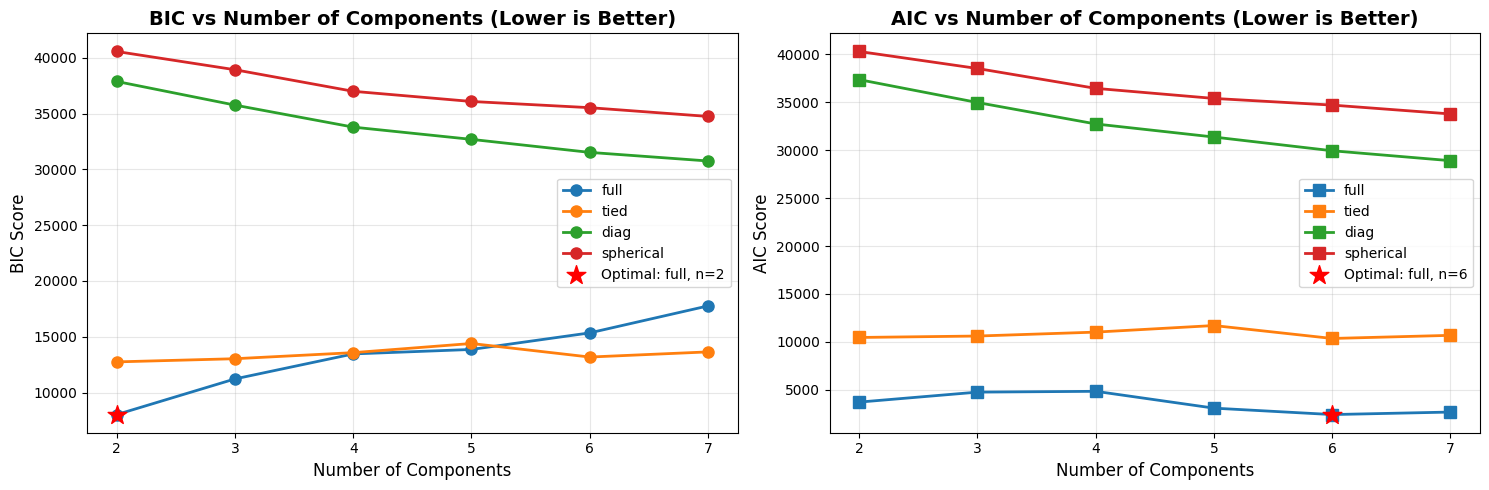

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for cov_type in covariance_types:
    data = df_results[df_results['cov_type'] == cov_type.value]
    ax1.plot(data['n_components'], data['BIC'],
             marker='o', label=cov_type.value, linewidth=2, markersize=8)
    ax2.plot(data['n_components'], data['AIC'],
             marker='s', label=cov_type.value, linewidth=2, markersize=8)

# Mark optimal points
ax1.scatter(best_bic['n_components'], best_bic['BIC'],
           color='red', s=200, marker='*', zorder=5,
           label=f"Optimal: {best_bic['cov_type']}, n={best_bic['n_components']:.0f}")
ax2.scatter(best_aic['n_components'], best_aic['AIC'],
           color='red', s=200, marker='*', zorder=5,
           label=f"Optimal: {best_aic['cov_type']}, n={best_aic['n_components']:.0f}")

ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('BIC Score', fontsize=12)
ax1.set_title('BIC vs Number of Components (Lower is Better)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('AIC Score', fontsize=12)
ax2.set_title('AIC vs Number of Components (Lower is Better)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Log-Likelihood curves

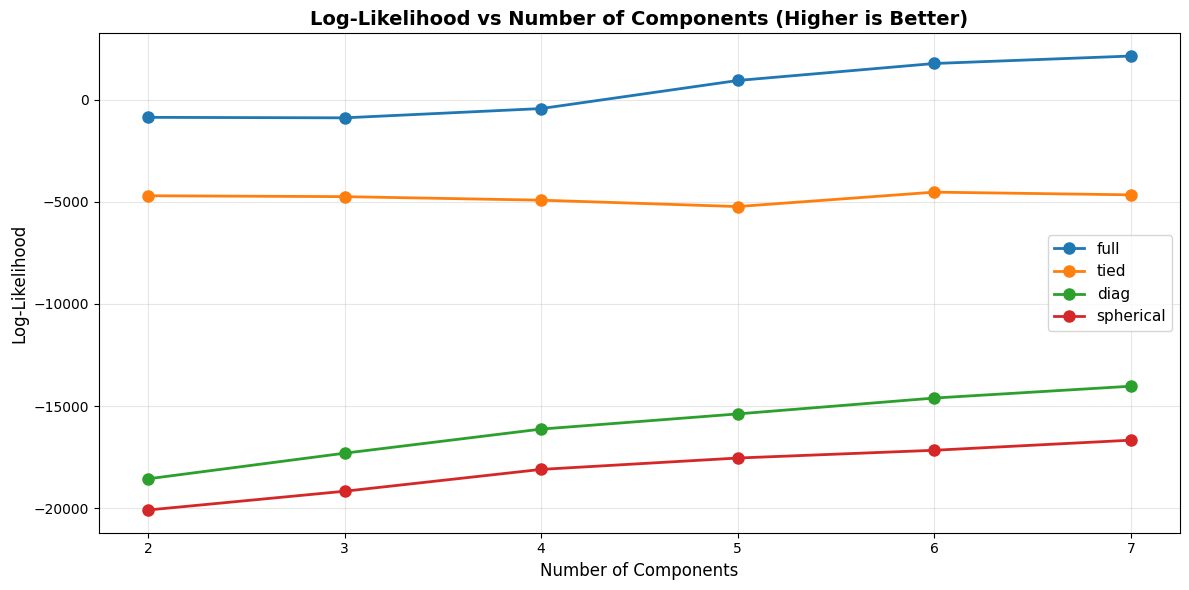

In [13]:
plt.figure(figsize=(12, 6))

for cov_type in covariance_types:
    data = df_results[df_results['cov_type'] == cov_type.value]
    plt.plot(data['n_components'], data['Log-Likelihood'],
             marker='o', label=cov_type.value, linewidth=2, markersize=8)

plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Log-Likelihood', fontsize=12)
plt.title('Log-Likelihood vs Number of Components (Higher is Better)',
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Retrain optimal model to get convergence history

Converged at iteration 65


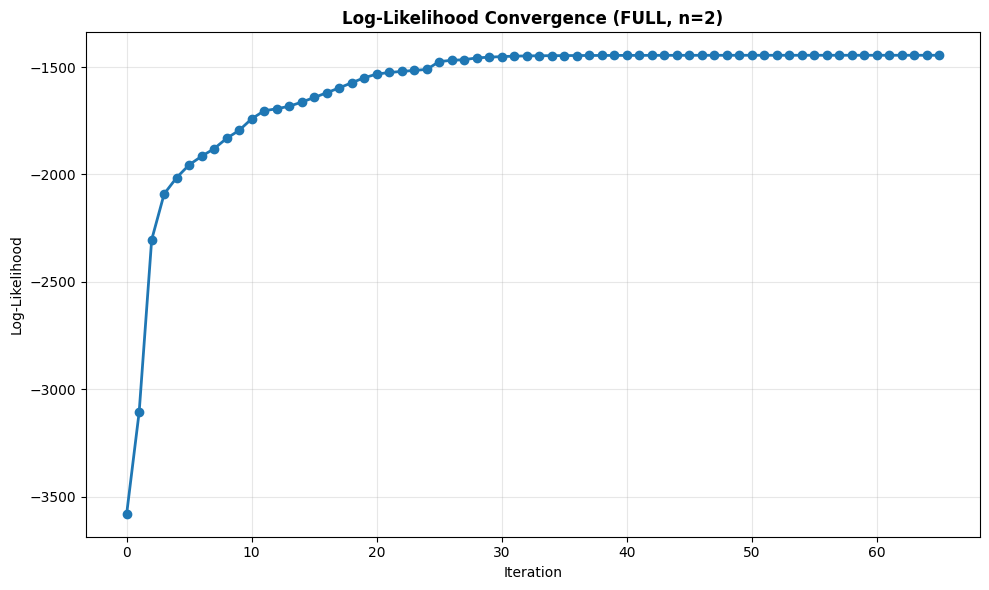

In [25]:
cov_type_map = {
    'full': CovarianceType.FULL,
    'tied': CovarianceType.TIED,
    'diag': CovarianceType.DIAGONAL,
    'spherical': CovarianceType.SPHERICAL
}

optimal_gmm = GMM(
    n_components=int(optimal_config['n_components']),
    cov_type=cov_type_map[optimal_config['cov_type']],
    tol=1e-3, max_iter=100, reg_covar=1e-3
)
optimal_gmm.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(optimal_gmm.log_likelihoods, marker='o', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title(f'Log-Likelihood Convergence ({optimal_config["cov_type"].upper()}, '
         f'n={optimal_config["n_components"]:.0f})', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Internal Validation Metrics


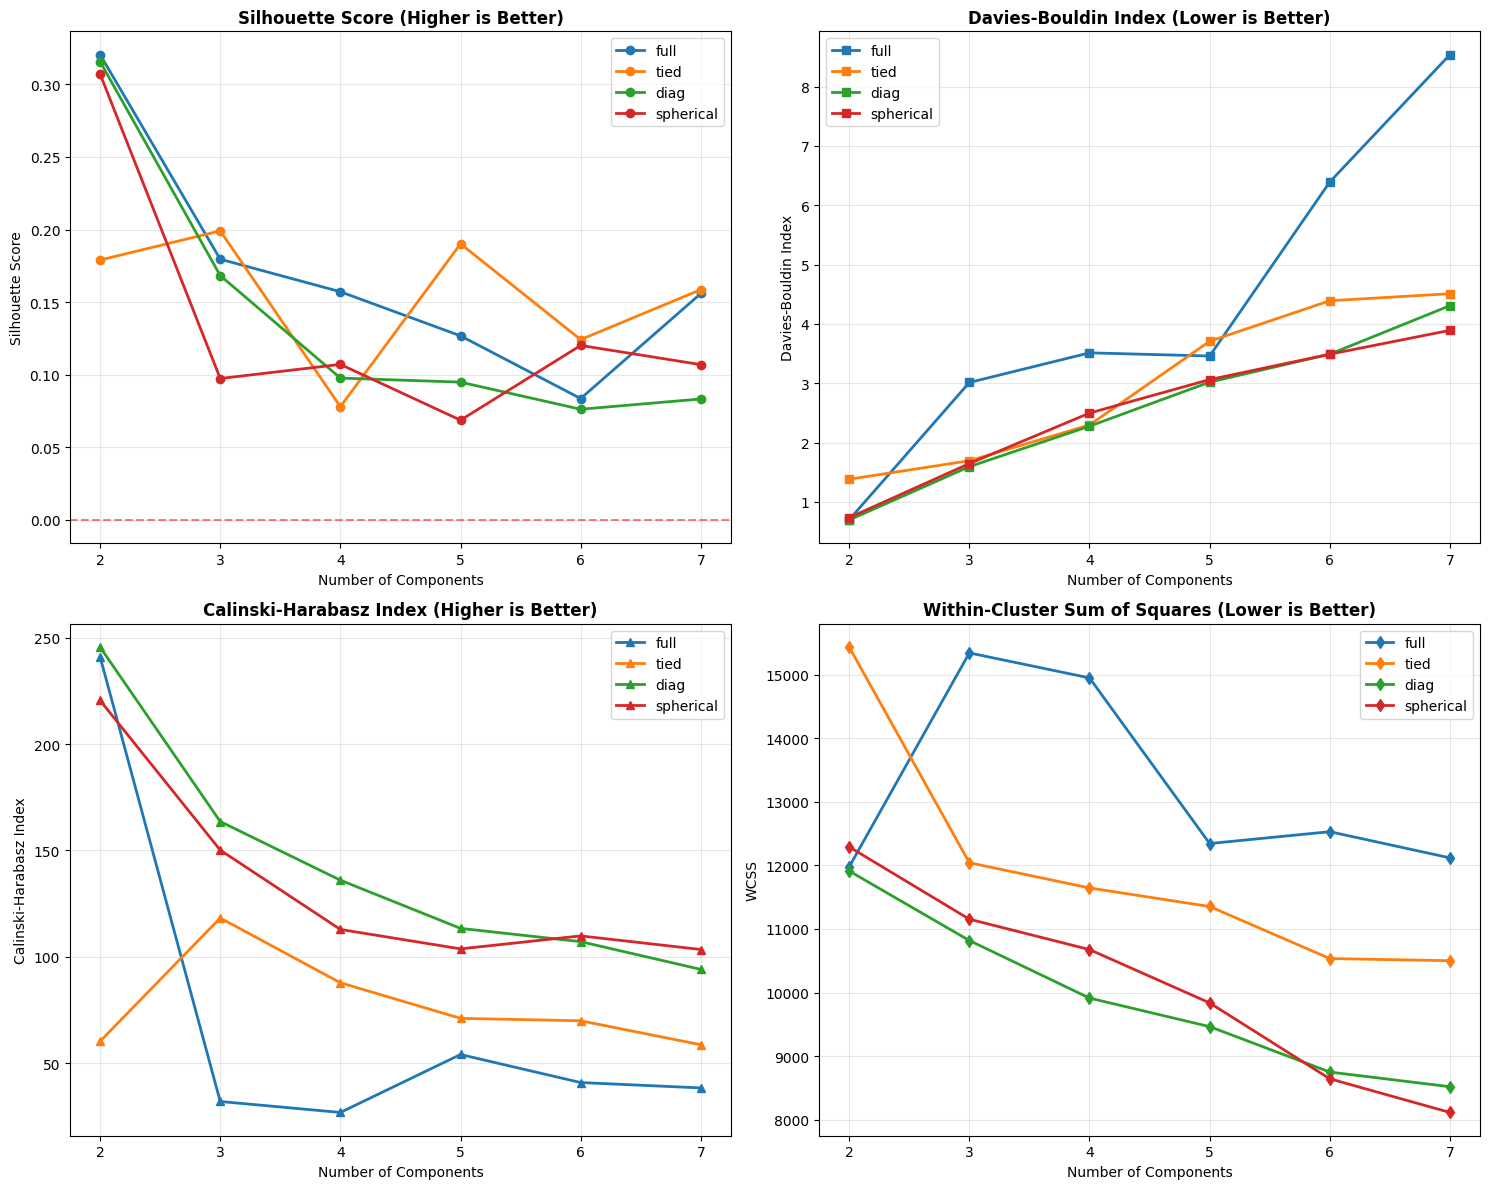

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Silhouette Score
for cov_type in covariance_types:
    data = df_results[df_results['cov_type'] == cov_type.value]
    axes[0, 0].plot(data['n_components'], data['Silhouette'],
                    marker='o', label=cov_type.value, linewidth=2)
axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Number of Components')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Silhouette Score (Higher is Better)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Davies-Bouldin Index
for cov_type in covariance_types:
    data = df_results[df_results['cov_type'] == cov_type.value]
    axes[0, 1].plot(data['n_components'], data['Davies-Bouldin'],
                    marker='s', label=cov_type.value, linewidth=2)
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].set_title('Davies-Bouldin Index (Lower is Better)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz Index
for cov_type in covariance_types:
    data = df_results[df_results['cov_type'] == cov_type.value]
    axes[1, 0].plot(data['n_components'], data['Calinski-Harabasz'],
                    marker='^', label=cov_type.value, linewidth=2)
axes[1, 0].set_xlabel('Number of Components')
axes[1, 0].set_ylabel('Calinski-Harabasz Index')
axes[1, 0].set_title('Calinski-Harabasz Index (Higher is Better)', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# WCSS
for cov_type in covariance_types:
    data = df_results[df_results['cov_type'] == cov_type.value]
    axes[1, 1].plot(data['n_components'], data['WCSS'],
                    marker='d', label=cov_type.value, linewidth=2)
axes[1, 1].set_xlabel('Number of Components')
axes[1, 1].set_ylabel('WCSS')
axes[1, 1].set_title('Within-Cluster Sum of Squares (Lower is Better)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### External Validation Metrics

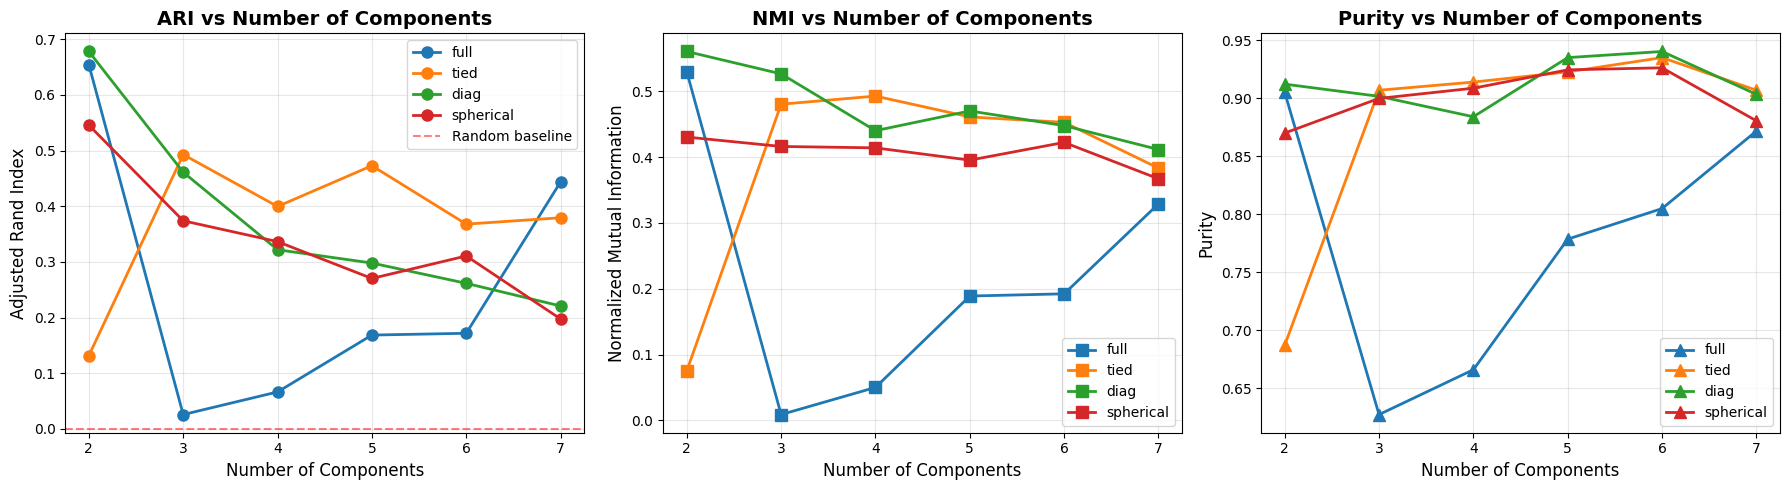

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# ARI
for cov_type in covariance_types:
    data = df_results[df_results['cov_type'] == cov_type.value]
    axes[0].plot(data['n_components'], data['ARI'],
                 marker='o', label=cov_type.value, linewidth=2, markersize=8)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Random baseline')
axes[0].set_xlabel('Number of Components', fontsize=12)
axes[0].set_ylabel('Adjusted Rand Index', fontsize=12)
axes[0].set_title('ARI vs Number of Components', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# NMI
for cov_type in covariance_types:
    data = df_results[df_results['cov_type'] == cov_type.value]
    axes[1].plot(data['n_components'], data['NMI'],
                 marker='s', label=cov_type.value, linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Normalized Mutual Information', fontsize=12)
axes[1].set_title('NMI vs Number of Components', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Purity
for cov_type in covariance_types:
    data = df_results[df_results['cov_type'] == cov_type.value]
    axes[2].plot(data['n_components'], data['Purity'],
                 marker='^', label=cov_type.value, linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Components', fontsize=12)
axes[2].set_ylabel('Purity', fontsize=12)
axes[2].set_title('Purity vs Number of Components', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 ### 2D Cluster Visualization

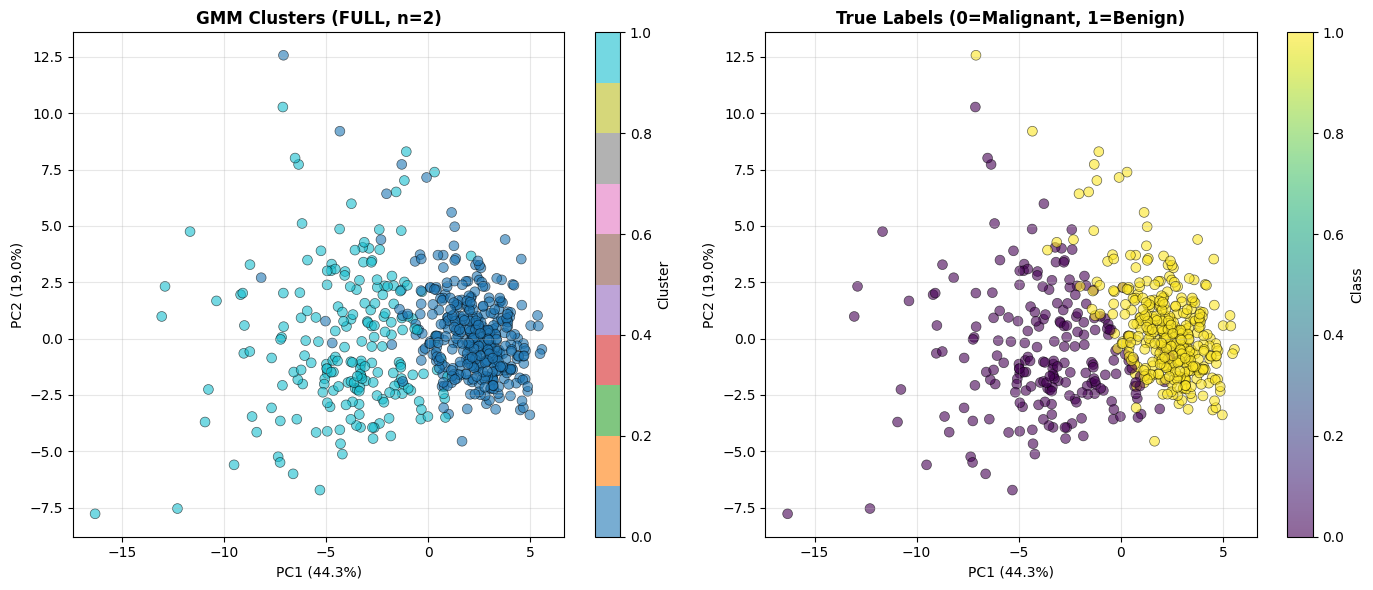

In [28]:
y_pred_optimal = optimal_gmm.predict(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Predicted clusters
scatter1 = ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=y_pred_optimal,
                      cmap='tab10', alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax1.set_title(f'GMM Clusters ({optimal_config["cov_type"].upper()}, '
             f'n={optimal_config["n_components"]:.0f})', fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster')
ax1.grid(True, alpha=0.3)

# True labels
scatter2 = ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=y,
                      cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
ax2.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax2.set_title('True Labels (0=Malignant, 1=Benign)', fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Class')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Confusion Matrix

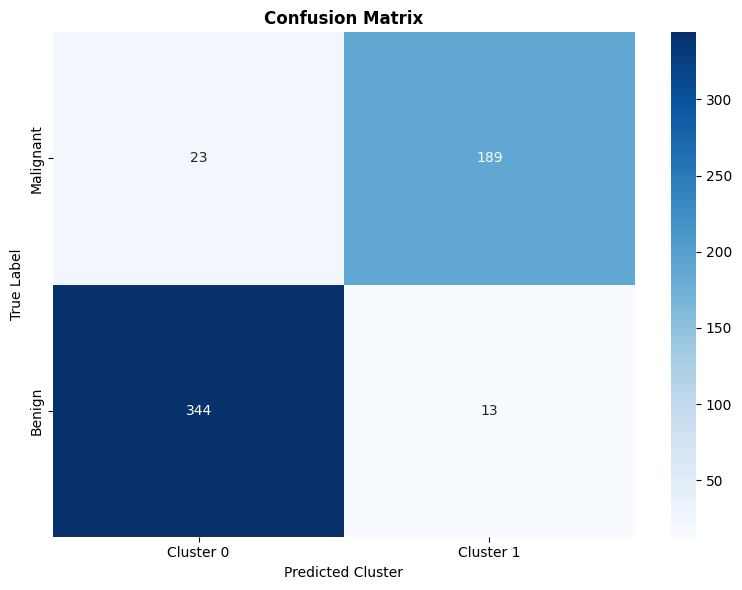


Cluster-to-Class Mapping:
  Cluster 0 → Benign (purity: 93.73%)
  Cluster 1 → Malignant (purity: 93.56%)


In [29]:
cm = sklearn_confusion_matrix(y, y_pred_optimal)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(cm.shape[1])],
            yticklabels=['Malignant', 'Benign'])
plt.ylabel('True Label')
plt.xlabel('Predicted Cluster')
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# Cluster mapping
print("\nCluster-to-Class Mapping:")
for cluster_id in range(cm.shape[1]):
    majority_class = np.argmax(cm[:, cluster_id])
    majority_count = cm[majority_class, cluster_id]
    total = cm[:, cluster_id].sum()
    purity_score = majority_count / total if total > 0 else 0
    class_name = "Malignant" if majority_class == 0 else "Benign"
    print(f"  Cluster {cluster_id} → {class_name} (purity: {purity_score:.2%})")